## Data Preprocessing & Feature Engineering

# Load Dataset

In [1]:
import pandas as pd

df = pd.read_csv("../data/raw/heart2.csv")
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target,source
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0,cleveland
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,1,cleveland
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1,cleveland
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0,cleveland
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0,cleveland


# Missing Value Analysis

In [5]:
df.isnull().sum()

age           0
sex           0
cp            0
trestbps     59
chol         30
fbs          90
restecg       2
thalach      55
exang        55
oldpeak      62
slope       309
ca          611
thal        486
target        0
source        0
dtype: int64

# for null value
# for numerical value

In [7]:
from sklearn.impute import SimpleImputer
num_inputer = SimpleImputer(strategy="median")

# for categorial

In [8]:
cat_imputer = SimpleImputer(strategy="most_frequent")

## Duplicate Removal

In [10]:
duplicates = df.duplicated().sum()
print(duplicates)

2


In [11]:
# Remove Duplicates
df.drop_duplicates()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target,source
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0,cleveland
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,1,cleveland
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1,cleveland
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0,cleveland
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0,cleveland
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
915,54.0,0.0,4.0,127.0,333.0,1.0,1.0,154.0,0.0,0.0,NaN,NaN,NaN,1,va
916,62.0,1.0,1.0,NaN,139.0,0.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,0,va
917,55.0,1.0,4.0,122.0,223.0,1.0,1.0,100.0,0.0,0.0,NaN,NaN,6.0,1,va
918,58.0,1.0,4.0,NaN,385.0,1.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,0,va


## Check Outliers

# Using Boxplots

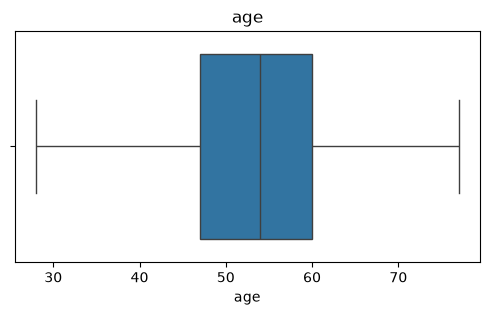

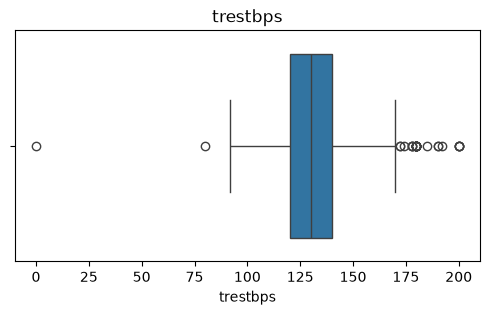

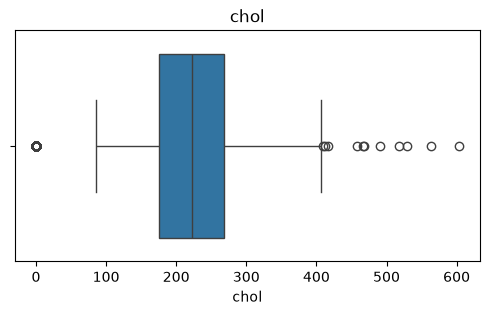

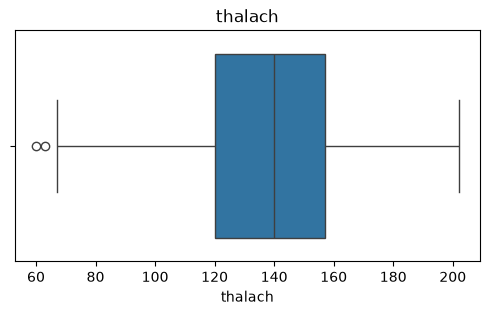

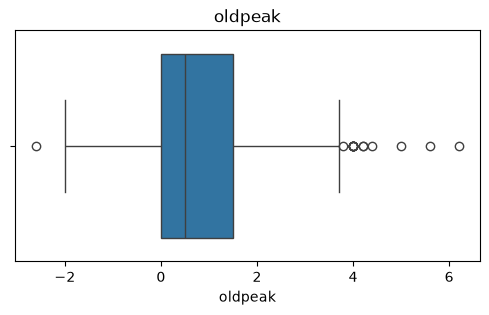

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

numeric_columns = [
    "age",
    "trestbps",
    "chol",
    "thalach",
    "oldpeak"
]


for col in numeric_columns:
    plt.figure(figsize=(6,3))
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

## Handle Outliers

# Instead of deleting them, researchers often use the IQR (Interquartile Range) method.

In [15]:
Q1 = df["chol"].quantile(0.25)
Q3 = df["chol"].quantile(0.25)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df["chol"] = df["chol"].clip(lower,upper)

In [26]:
X = df.drop(columns=['target','source'])
Y = df["target"]

print(X)
print(Y)

      age  sex   cp  trestbps   chol  fbs  restecg  thalach  exang  oldpeak  \
0    63.0  1.0  1.0     145.0  175.0  1.0      2.0    150.0    0.0      2.3   
1    67.0  1.0  4.0     160.0  175.0  0.0      2.0    108.0    1.0      1.5   
2    67.0  1.0  4.0     120.0  175.0  0.0      2.0    129.0    1.0      2.6   
3    37.0  1.0  3.0     130.0  175.0  0.0      0.0    187.0    0.0      3.5   
4    41.0  0.0  2.0     130.0  175.0  0.0      2.0    172.0    0.0      1.4   
..    ...  ...  ...       ...    ...  ...      ...      ...    ...      ...   
915  54.0  0.0  4.0     127.0  175.0  1.0      1.0    154.0    0.0      0.0   
916  62.0  1.0  1.0       NaN  175.0  0.0      1.0      NaN    NaN      NaN   
917  55.0  1.0  4.0     122.0  175.0  1.0      1.0    100.0    0.0      0.0   
918  58.0  1.0  4.0       NaN  175.0  1.0      2.0      NaN    NaN      NaN   
919  62.0  1.0  2.0     120.0  175.0  0.0      2.0     93.0    1.0      0.0   

     slope   ca  thal  
0      3.0  0.0   6.0  
1  

## Feature Scaling

Algorithms like:

SVM
KNN
Logistic Regression

perform better with scaled features.

In [27]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [28]:
print(X_scaled)

[[ 1.00738556  0.51693097 -2.4181517  ...  1.98648055 -0.72406385
   0.4760083 ]
 [ 1.43203377  0.51693097  0.80605057 ...  0.37031595  2.48745382
  -1.08904929]
 [ 1.43203377  0.51693097  0.80605057 ...  0.37031595  1.41694793
   0.99769417]
 ...
 [ 0.15808914  0.51693097  0.80605057 ...         nan         nan
   0.4760083 ]
 [ 0.4765753   0.51693097  0.80605057 ...         nan         nan
          nan]
 [ 0.90122351  0.51693097 -1.34341761 ...         nan         nan
          nan]]


## Train-Test Split

Use an 80/20 split with stratification to preserve the class distribution.

In [30]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    Y,
    test_size=0.20,
    random_state=42,
    stratify=Y
)

## Save Processed Dataset

In [31]:
processed = pd.DataFrame(X_train)

processed.to_csv(
    "../data/processed/train.csv",
    index=False
)

## Feature Importance (Research)

Researchers identify which variables influence prediction the most.

Example with Random Forest:

In [32]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)

rf.fit(X_train, y_train)

importance = rf.feature_importances_

In [33]:
# creating data frame
feature_importance = pd.DataFrame({

    "Feature": X.columns,

    "Importance": importance

}).sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance)

     Feature  Importance
2         cp    0.152703
7    thalach    0.137215
0        age    0.136755
9    oldpeak    0.096243
3   trestbps    0.086311
10     slope    0.076071
8      exang    0.075743
12      thal    0.064860
11        ca    0.059022
5        fbs    0.041262
1        sex    0.037465
6    restecg    0.030935
4       chol    0.005414


## Visualize Feature Importance

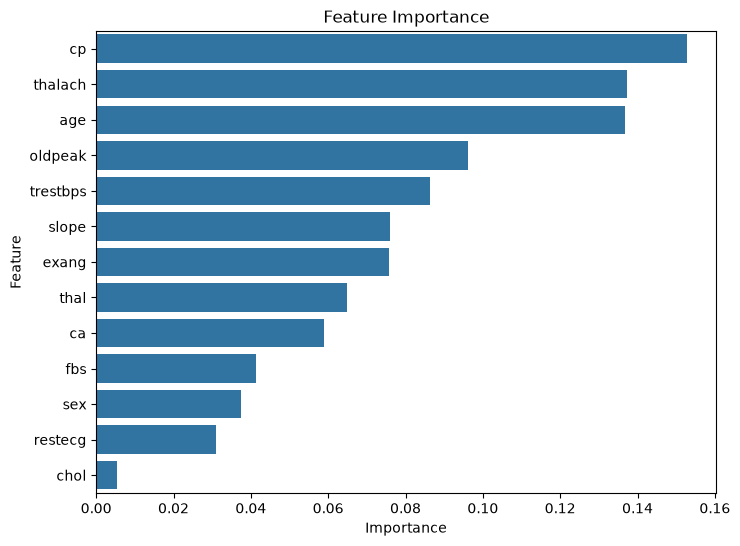

In [34]:
plt.figure(figsize=(8,6))

sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature"
)

plt.title("Feature Importance")

plt.show()

## Research Observation

find features like:

Chest Pain (cp)
Oldpeak
Number of Major Vessels (ca)
Thalassemia (thal)
Exercise-Induced Angina (exang)

among the most influential predictors.  actual results should be based on the trained model, not assumptions.

## Save the Scaler


In [35]:
import joblib
joblib.dump(
    scaler,
    "../models/scaler.pkl"
)

['../models/scaler.pkl']

In [37]:
import pandas as pd

# Convert scaled arrays back to DataFrames
X_train_df = pd.DataFrame(X_train, columns=X.columns)
X_test_df = pd.DataFrame(X_test, columns=X.columns)

y_train_df = pd.DataFrame(y_train, columns=["target"])
y_test_df = pd.DataFrame(y_test, columns=["target"])

# Save them
X_train_df.to_csv("../data/processed/X_train.csv", index=False)
X_test_df.to_csv("../data/processed/X_test.csv", index=False)

y_train_df.to_csv("../data/processed/y_train.csv", index=False)
y_test_df.to_csv("../data/processed/y_test.csv", index=False)